# 01 — Detect Issues: Анализ качества данных

**Датасет:** data/processed/perfumes_merged.csv  
**Задача:** Регрессия — предсказание рейтинга духов (`rating_value`)  
**Цель:** Найти все проблемы качества данных, оценить severity, вычислить Quality Score.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.insert(0, "..")
from scripts.quality_utils import detect_all

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

DATA_PATH  = "../data/processed/perfumes_merged.csv"
REPORT_PATH = "../data/reports/quality_report.json"
TARGET_COL = "rating_value"

print("Imports OK")


Imports OK


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head(3)


Shape: (23800, 18)
Columns: ['url', 'perfume', 'brand', 'country', 'gender', 'rating_value', 'rating_count', 'year', 'top', 'middle', 'base', 'perfumer1', 'perfumer2', 'mainaccord1', 'mainaccord2', 'mainaccord3', 'mainaccord4', 'mainaccord5']
Memory: 25.1 MB


,url,perfume,brand,country,gender,rating_value,rating_count,year,top,middle,base,perfumer1,perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,https://www.fragrantica.com/perfume/xerjoff/ac...,accento-overdose-pride-edition,Xerjoff,Italy,unisex,1.42,201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2024,Jean-Paul-Gaultier,France,women,1.86,70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,https://www.fragrantica.com/perfume/jean-paul-...,classique-pride-2023,Jean-Paul-Gaultier,France,unisex,1.91,285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky


In [3]:
print("Типы данных и базовая статистика:")
print(df.dtypes)
print()
print(df.describe().T.round(3))


Типы данных и базовая статистика:
url              object
perfume          object
brand            object
country          object
gender           object
rating_value    float64
rating_count      int64
year            float64
top              object
middle           object
base             object
perfumer1        object
perfumer2        object
mainaccord1      object
mainaccord2      object
mainaccord3      object
mainaccord4      object
mainaccord5      object
dtype: object

                count      mean       std      min      25%      50%      75%  \
rating_value  23800.0     3.961     0.278     1.42     3.79     3.97     4.15   
rating_count  23800.0   508.327  1480.197    26.00    56.00   127.00   361.00   
year          21791.0  2012.591    13.011  1786.00  2010.00  2015.00  2019.00   

                   max  
rating_value      4.93  
rating_count  31179.00  
year           2025.00  


## 1. Пропущенные значения (Missing Values)

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = (pd.DataFrame({"count": missing, "percent": missing_pct})
              .query("count > 0")
              .sort_values("percent", ascending=False))

print(f"Всего пропусков: {missing.sum()} из {df.size} ({missing.sum()/df.size*100:.2f}%)")
print()
print(missing_df.to_string())


Всего пропусков: 26230 из 428400 (6.12%)

             count  percent
perfumer2    22483    94.47
year          2009     8.44
mainaccord5   1002     4.21
mainaccord4    420     1.76
mainaccord3    150     0.63
mainaccord2     53     0.22
country         40     0.17
mainaccord1     40     0.17
gender          23     0.10
middle           5     0.02
base             5     0.02


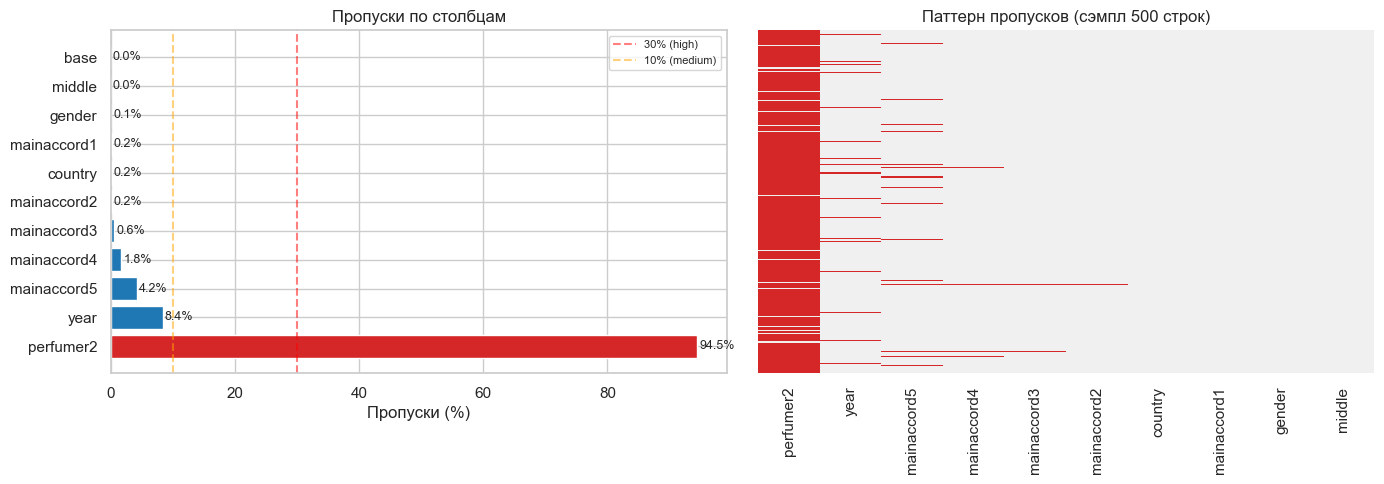

Сохранено: data/reports/fig_missing.png


In [5]:
if len(missing_df) == 0:
    print("Пропусков не обнаружено!")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    ax = axes[0]
    pct_vals = missing_df["percent"].values
    colors = ["#d62728" if p > 30 else "#ff7f0e" if p > 10 else "#1f77b4"
              for p in pct_vals]
    bars = ax.barh(missing_df.index, pct_vals, color=colors)
    ax.axvline(30, color="red", ls="--", alpha=0.5, label="30% (high)")
    ax.axvline(10, color="orange", ls="--", alpha=0.5, label="10% (medium)")
    ax.set_xlabel("Пропуски (%)")
    ax.set_title("Пропуски по столбцам")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, pct_vals):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=9)

    # Heatmap паттернов
    ax2 = axes[1]
    sample_cols = missing_df.index[:10].tolist()
    sample_size = min(500, len(df))
    sns.heatmap(df[sample_cols].sample(sample_size, random_state=42).isnull(),
                cbar=False, yticklabels=False,
                cmap=["#f0f0f0", "#d62728"], ax=ax2)
    ax2.set_title(f"Паттерн пропусков (сэмпл {sample_size} строк)")

    plt.tight_layout()
    plt.savefig("../data/reports/fig_missing.png", bbox_inches="tight")
    plt.show()
    print("Сохранено: data/reports/fig_missing.png")


## 2. Дубликаты (Duplicates)

In [6]:
n_dup = int(df.duplicated().sum())
dup_pct = n_dup / len(df) * 100
sev = "HIGH" if dup_pct > 5 else "MEDIUM" if dup_pct > 1 else "LOW"
print(f"Полных дубликатов: {n_dup} ({dup_pct:.2f}%) — severity: {sev}")

if n_dup > 0:
    print("\nПримеры дублирующихся строк:")
    dup_rows = df[df.duplicated(keep=False)].sort_values(list(df.columns[:3]))
    display(dup_rows.head(6))
else:
    print("Полных дубликатов не обнаружено.")

# Частичные дубликаты по ключевым полям
key_cols = [c for c in ["url", "perfume", "brand"] if c in df.columns]
if key_cols:
    n_partial = int(df.duplicated(subset=key_cols).sum())
    print(f"\nЧастичных дубликатов по {key_cols}: {n_partial} ({n_partial/len(df)*100:.2f}%)")


Полных дубликатов: 0 (0.00%) — severity: LOW
Полных дубликатов не обнаружено.

Частичных дубликатов по ['url', 'perfume', 'brand']: 0 (0.00%)


## 3. Выбросы (Outliers)

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых столбцов: {len(numeric_cols)} — {numeric_cols}")

outlier_rows = []
for col in numeric_cols:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    pct_iqr = n_iqr / len(s) * 100
    z = np.abs(stats.zscore(s))
    n_z = int((z > 3).sum())
    pct_z = n_z / len(s) * 100
    sev = "HIGH" if pct_iqr > 10 else "MEDIUM" if pct_iqr > 3 else "LOW"
    outlier_rows.append({
        "column": col, "n_iqr": n_iqr, "pct_iqr": round(pct_iqr, 2),
        "n_zscore": n_z, "pct_zscore": round(pct_z, 2),
        "mean": round(float(s.mean()), 3), "std": round(float(s.std()), 3),
        "min": round(float(s.min()), 3), "max": round(float(s.max()), 3),
        "skewness": round(float(s.skew()), 3), "severity": sev
    })

outlier_df = pd.DataFrame(outlier_rows)
print("\nСводка по выбросам:")
print(outlier_df.to_string(index=False))


Числовых столбцов: 3 — ['rating_value', 'rating_count', 'year']

Сводка по выбросам:
      column  n_iqr  pct_iqr  n_zscore  pct_zscore     mean      std     min      max  skewness severity
rating_value    299     1.26       140        0.59    3.961    0.278    1.42     4.93    -0.461      LOW
rating_count   3035    12.75       394        1.66  508.327 1480.197   26.00 31179.00     8.869     HIGH
        year   1331     6.11       317        1.45 2012.591   13.011 1786.00  2025.00    -5.580   MEDIUM


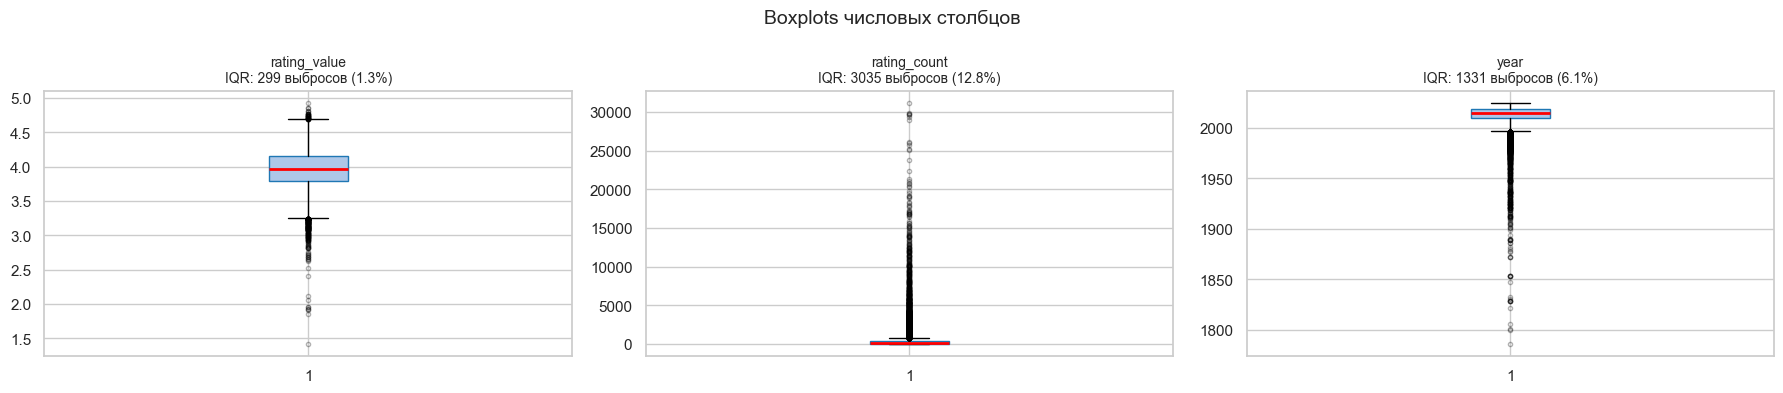

Сохранено: data/reports/fig_boxplots.png


In [8]:
# Boxplots
n = len(numeric_cols)
ncols_plot = min(3, n)
nrows_plot = (n + ncols_plot - 1) // ncols_plot
fig, axes = plt.subplots(nrows_plot, ncols_plot,
                         figsize=(6*ncols_plot, 4*nrows_plot), squeeze=False)
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes_flat[i]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#aec7e8", color="#1f77b4"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=3, alpha=0.3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = int(((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum())
    ax.set_title(f"{col}\nIQR: {n_out} выбросов ({n_out/len(data)*100:.1f}%)", fontsize=10)

for j in range(len(numeric_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Boxplots числовых столбцов", fontsize=14)
plt.tight_layout()
plt.savefig("../data/reports/fig_boxplots.png", bbox_inches="tight")
plt.show()
print("Сохранено: data/reports/fig_boxplots.png")


## 4. Целевая переменная: `rating_value`

Задача — регрессия. Анализируем распределение целевой переменной.

Статистика rating_value:
count    23800.000
mean         3.961
std          0.278
min          1.420
25%          3.790
50%          3.970
75%          4.150
max          4.930
Name: rating_value, dtype: float64

Асимметрия (skewness): -0.461
Пропусков в target: 0


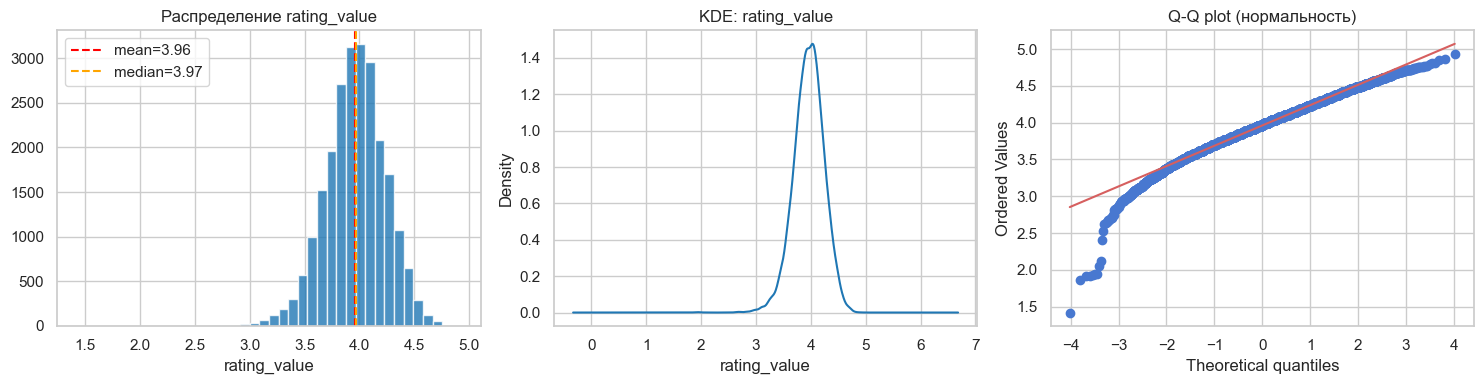

Сохранено: data/reports/fig_target_dist.png


In [9]:
target = df[TARGET_COL].dropna()
print(f"Статистика {TARGET_COL}:")
print(target.describe().round(3))
print(f"\nАсимметрия (skewness): {target.skew():.3f}")
print(f"Пропусков в target: {df[TARGET_COL].isnull().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(target, bins=40, color="#1f77b4", edgecolor="white", alpha=0.8)
axes[0].axvline(target.mean(), color="red", ls="--", label=f"mean={target.mean():.2f}")
axes[0].axvline(target.median(), color="orange", ls="--", label=f"median={target.median():.2f}")
axes[0].set_xlabel(TARGET_COL)
axes[0].set_title("Распределение rating_value")
axes[0].legend()

# KDE
target.plot.kde(ax=axes[1], color="#1f77b4")
axes[1].set_title("KDE: rating_value")
axes[1].set_xlabel(TARGET_COL)

# QQ-plot
stats.probplot(target, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot (нормальность)")

plt.tight_layout()
plt.savefig("../data/reports/fig_target_dist.png", bbox_inches="tight")
plt.show()
print("Сохранено: data/reports/fig_target_dist.png")


## 5. Сводный Quality Report

In [10]:
import os
os.makedirs("../data/reports", exist_ok=True)

report = detect_all(df, target_col=TARGET_COL, dataset_name="perfumes_merged")

print(f"Quality Score: {report.quality_score}/100")
print(f"Всего проблем: {len(report.issues)}")

severity_order = ["critical", "high", "medium", "low"]
severity_icons = {"critical": "🔴", "high": "🟠", "medium": "🟡", "low": "🟢"}

for sev in severity_order:
    issues = [i for i in report.issues if i.severity == sev]
    if issues:
        print(f"\n{severity_icons[sev]} {sev.upper()} ({len(issues)})")
        for issue in issues:
            print(f"   [{issue.type}] {issue.column}: {issue.description}")


Quality Score: 52.5/100
Всего проблем: 13

🔴 CRITICAL (1)
   [missing] perfumer2: Пропущено 22483 значений (94.5%)

🟠 HIGH (1)
   [outlier] rating_count: IQR: 3035 выбросов (12.8%), Z-score: 394

🟡 MEDIUM (1)
   [outlier] year: IQR: 1331 выбросов (6.1%), Z-score: 317

🟢 LOW (10)
   [missing] country: Пропущено 40 значений (0.2%)
   [missing] gender: Пропущено 23 значений (0.1%)
   [missing] year: Пропущено 2009 значений (8.4%)
   [missing] middle: Пропущено 5 значений (0.0%)
   [missing] base: Пропущено 5 значений (0.0%)
   [missing] mainaccord1: Пропущено 40 значений (0.2%)
   [missing] mainaccord2: Пропущено 53 значений (0.2%)
   [missing] mainaccord3: Пропущено 150 значений (0.6%)
   [missing] mainaccord4: Пропущено 420 значений (1.8%)
   [missing] mainaccord5: Пропущено 1002 значений (4.2%)


In [11]:
# Сводная таблица
issues_data = [{
    "Тип": i.type, "Severity": i.severity, "Столбец": i.column,
    "Кол-во": i.count, "Процент": f"{i.percentage:.1f}%", "Описание": i.description,
} for i in report.issues]
issues_table = pd.DataFrame(issues_data)
print("СВОДНАЯ ТАБЛИЦА ПРОБЛЕМ:")
print(issues_table.to_string(index=False))


СВОДНАЯ ТАБЛИЦА ПРОБЛЕМ:
    Тип Severity      Столбец  Кол-во Процент                                 Описание
missing      low      country      40    0.2%             Пропущено 40 значений (0.2%)
missing      low       gender      23    0.1%             Пропущено 23 значений (0.1%)
missing      low         year    2009    8.4%           Пропущено 2009 значений (8.4%)
missing      low       middle       5    0.0%              Пропущено 5 значений (0.0%)
missing      low         base       5    0.0%              Пропущено 5 значений (0.0%)
missing critical    perfumer2   22483   94.5%         Пропущено 22483 значений (94.5%)
missing      low  mainaccord1      40    0.2%             Пропущено 40 значений (0.2%)
missing      low  mainaccord2      53    0.2%             Пропущено 53 значений (0.2%)
missing      low  mainaccord3     150    0.6%            Пропущено 150 значений (0.6%)
missing      low  mainaccord4     420    1.8%            Пропущено 420 значений (1.8%)
missing      low  

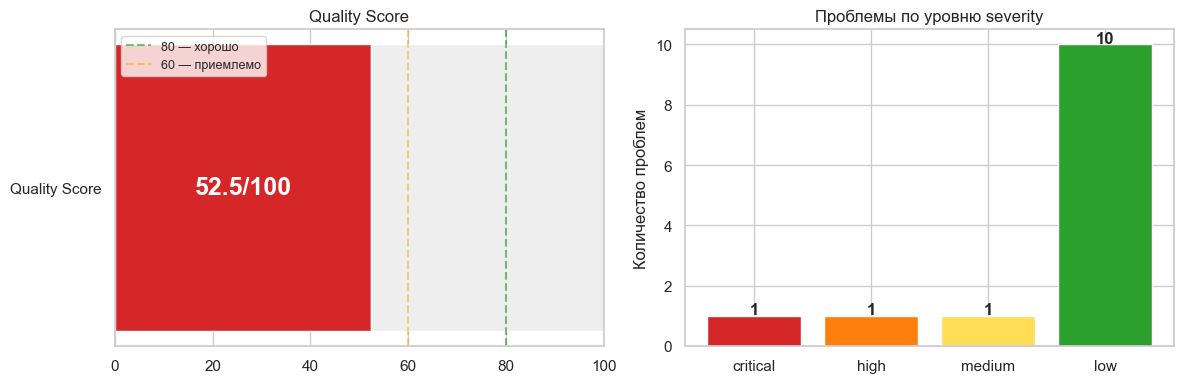

In [12]:
# Визуализация Quality Score и распределения проблем
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score bar
ax = axes[0]
score = report.quality_score
color = "#2ca02c" if score >= 80 else "#ff7f0e" if score >= 60 else "#d62728"
ax.barh(["Quality Score"], [score], color=color, height=0.4)
ax.barh(["Quality Score"], [100 - score], left=score, color="#eeeeee", height=0.4)
ax.set_xlim(0, 100)
ax.axvline(80, color="green", ls="--", alpha=0.5, label="80 — хорошо")
ax.axvline(60, color="orange", ls="--", alpha=0.5, label="60 — приемлемо")
ax.text(score / 2, 0, f"{score}/100", ha="center", va="center",
        fontsize=18, fontweight="bold", color="white")
ax.set_title("Quality Score")
ax.legend(fontsize=9)

# Issues by severity
ax2 = axes[1]
severity_order = ["critical", "high", "medium", "low"]
colors_map = {"critical": "#d62728", "high": "#ff7f0e", "medium": "#ffdd57", "low": "#2ca02c"}
sev_counts = {s: len([i for i in report.issues if i.severity == s])
              for s in severity_order}
sev_counts = {k: v for k, v in sev_counts.items() if v > 0}
if sev_counts:
    ax2.bar(sev_counts.keys(), sev_counts.values(),
            color=[colors_map[s] for s in sev_counts])
    for x, (k, v) in enumerate(sev_counts.items()):
        ax2.text(x, v + 0.05, str(v), ha="center", fontweight="bold")
    ax2.set_title("Проблемы по уровню severity")
    ax2.set_ylabel("Количество проблем")

plt.tight_layout()
plt.savefig("../data/reports/fig_quality_score.png", bbox_inches="tight")
plt.show()


In [13]:
# Сохраняем JSON-отчёт
report.save(REPORT_PATH)
print(f"✅ Отчёт сохранён: {REPORT_PATH}")
print(f"   Quality Score: {report.quality_score}/100")
print(f"   Проблем найдено: {len(report.issues)}")


✅ Отчёт сохранён: ../data/reports/quality_report.json
   Quality Score: 52.5/100
   Проблем найдено: 13
